# Lab 4: SARSA and Q-learning on CliffWalking-v0


In [1]:
import numpy as np
import gymnasium as gym
import matplotlib.pyplot as plt
import matplotlib.patches as patches

## 1. Core algorithms (ε-greedy, online TD updates)

In [2]:
def eps_greedy(Q, s, eps, nA, rng):
    if rng.random() < eps:
        return int(rng.choice(nA))
    return int(np.argmax(Q[s]))

def sarsa(env, n_episodes, alpha, eps, gamma, seed):
    rng = np.random.default_rng(seed)
    nS, nA = env.observation_space.n, env.action_space.n
    Q = np.zeros((nS, nA))
    returns = np.zeros(n_episodes)
    for ep in range(n_episodes):
        s, _ = env.reset(seed=int(seed * 10007 + ep))
        e = eps(ep) if callable(eps) else eps
        a = eps_greedy(Q, s, e, nA, rng)
        total, done = 0.0, False
        while not done:
            s2, r, terminated, truncated, _ = env.step(a)
            done = terminated or truncated
            a2 = eps_greedy(Q, s2, e, nA, rng)
            target = r + (0.0 if terminated else gamma * Q[s2, a2])
            Q[s, a] += alpha * (target - Q[s, a])
            s, a, total = s2, a2, total + r
        returns[ep] = total
    return Q, returns

def qlearning(env, n_episodes, alpha, eps, gamma, seed):
    rng = np.random.default_rng(seed)
    nS, nA = env.observation_space.n, env.action_space.n
    Q = np.zeros((nS, nA))
    returns = np.zeros(n_episodes)
    for ep in range(n_episodes):
        s, _ = env.reset(seed=int(seed * 10007 + ep))
        e = eps(ep) if callable(eps) else eps
        total, done = 0.0, False
        while not done:
            a = eps_greedy(Q, s, e, nA, rng)
            s2, r, terminated, truncated, _ = env.step(a)
            done = terminated or truncated
            target = r + (0.0 if terminated else gamma * np.max(Q[s2]))
            Q[s, a] += alpha * (target - Q[s, a])
            s, total = s2, total + r
        returns[ep] = total
    return Q, returns


## 2. Run 30 seeds, compute 95% CIs

In [3]:
def run_many(alg, n_seeds, n_episodes, alpha, eps, gamma):
    all_ret, Qs = np.zeros((n_seeds, n_episodes)), []
    for i in range(n_seeds):
        env = gym.make("CliffWalking-v0")
        Q, rets = alg(env, n_episodes, alpha, eps, gamma, seed=i)
        all_ret[i], _ = rets, Qs.append(Q)
        env.close()
    return all_ret, Qs

def ci95(arr):
    mean = arr.mean(axis=0)
    se = arr.std(axis=0, ddof=1) / np.sqrt(arr.shape[0])
    return mean, mean - 1.96 * se, mean + 1.96 * se

def smooth(x, w=20):
    if x.ndim == 1:
        return np.convolve(x, np.ones(w)/w, mode="valid")
    return np.stack([np.convolve(r, np.ones(w)/w, mode="valid") for r in x])

N_SEEDS, N_EPISODES, ALPHA, EPS, GAMMA = 30, 500, 0.5, 0.1, 1.0
sarsa_ret, sarsa_Qs = run_many(sarsa, N_SEEDS, N_EPISODES, ALPHA, EPS, GAMMA)
ql_ret, ql_Qs = run_many(qlearning, N_SEEDS, N_EPISODES, ALPHA, EPS, GAMMA)


## 3. Learning curves with 95% CI

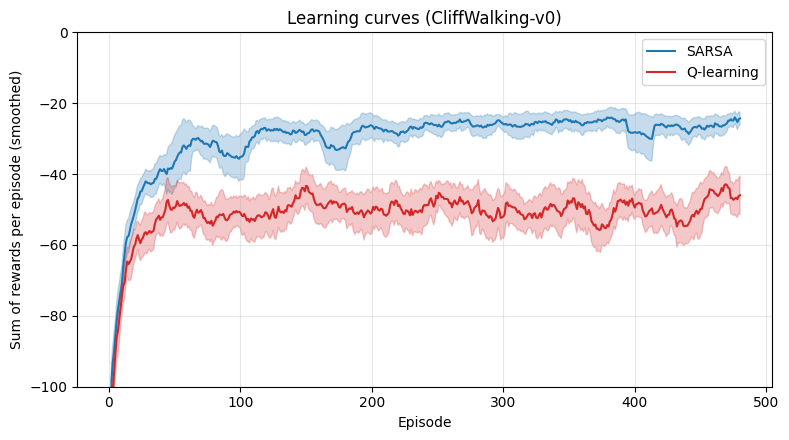

In [4]:
s_m, s_lo, s_hi = ci95(smooth(sarsa_ret))
q_m, q_lo, q_hi = ci95(smooth(ql_ret))
x = np.arange(len(s_m))
plt.figure(figsize=(8, 4.5))
plt.plot(x, s_m, label="SARSA", color="#1f77b4")
plt.fill_between(x, s_lo, s_hi, alpha=0.25, color="#1f77b4")
plt.plot(x, q_m, label="Q-learning", color="#d62728")
plt.fill_between(x, q_lo, q_hi, alpha=0.25, color="#d62728")
plt.xlabel("Episode"); plt.ylabel("Sum of rewards per episode (smoothed)")
plt.ylim(-100, 0); plt.legend(); plt.grid(alpha=0.3); plt.title("Learning curves (CliffWalking-v0)")
plt.tight_layout(); plt.show()


## 4. Greedy policy arrows and trajectories

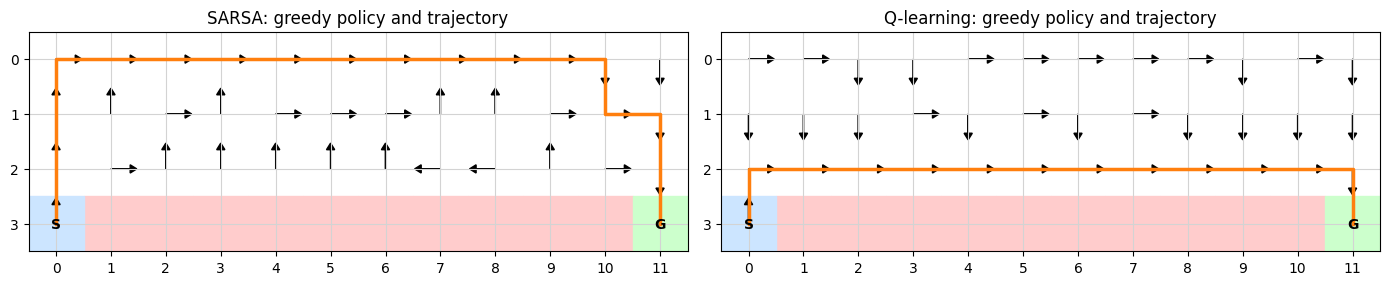

In [5]:
def greedy_trajectory(Q, max_steps=50):
    env = gym.make("CliffWalking-v0")
    s, _ = env.reset(seed=0)
    path = [s]
    for _ in range(max_steps):
        a = int(np.argmax(Q[s]))
        s, _, term, trunc, _ = env.step(a)
        path.append(s)
        if term or trunc: break
    env.close()
    return path

def plot_policy(Q, ax, title):
    dirs = {0: (0, -0.35), 1: (0.35, 0), 2: (0, 0.35), 3: (-0.35, 0)}
    ax.set_xlim(-0.5, 11.5); ax.set_ylim(3.5, -0.5); ax.set_aspect("equal")
    ax.set_xticks(range(12)); ax.set_yticks(range(4)); ax.grid(True, color="lightgray")
    for c in range(1, 11): ax.add_patch(patches.Rectangle((c-0.5, 2.5), 1, 1, color="#ffcccc"))
    ax.add_patch(patches.Rectangle((-0.5, 2.5), 1, 1, color="#cce5ff"))
    ax.add_patch(patches.Rectangle((10.5, 2.5), 1, 1, color="#ccffcc"))
    ax.text(0, 3, "S", ha="center", va="center", fontweight="bold")
    ax.text(11, 3, "G", ha="center", va="center", fontweight="bold")
    for r in range(4):
        for c in range(12):
            if (r == 3 and 1 <= c <= 11): continue
            a = int(np.argmax(Q[r*12+c])); dx, dy = dirs[a]
            ax.arrow(c, r, dx, dy, head_width=0.15, head_length=0.12, fc="black", ec="black")
    path = greedy_trajectory(Q)
    ax.plot([s % 12 for s in path], [s // 12 for s in path], color="#ff7f0e", linewidth=2.5)
    ax.set_title(title)

fig, axes = plt.subplots(1, 2, figsize=(14, 4.2))
plot_policy(sarsa_Qs[-1], axes[0], "SARSA: greedy policy and trajectory")
plot_policy(ql_Qs[-1], axes[1], "Q-learning: greedy policy and trajectory")
plt.tight_layout(); plt.show()


## 5. Value function heatmaps

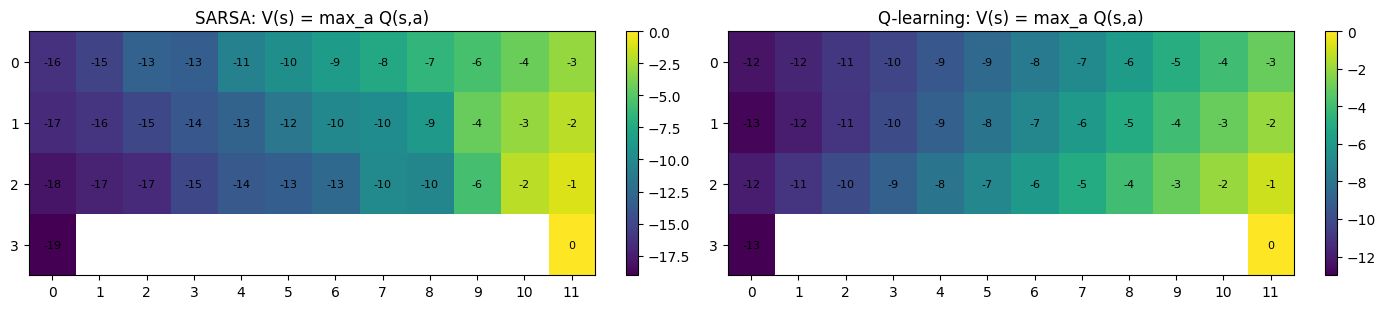

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(14, 3.2))
for ax, Q, name in zip(axes, [sarsa_Qs[-1], ql_Qs[-1]], ["SARSA", "Q-learning"]):
    V = np.max(Q, axis=1).reshape(4, 12).copy()
    V[3, 1:11] = np.nan; V[3, 11] = 0.0
    im = ax.imshow(V, cmap="viridis", aspect="auto")
    ax.set_title(f"{name}: V(s) = max_a Q(s,a)")
    ax.set_xticks(range(12)); ax.set_yticks(range(4))
    for r in range(4):
        for c in range(12):
            if not np.isnan(V[r, c]):
                ax.text(c, r, f"{V[r, c]:.0f}", ha="center", va="center",
                        color="white" if V[r, c] < -40 else "black", fontsize=8)
    fig.colorbar(im, ax=ax, fraction=0.03)
plt.tight_layout(); plt.show()


## 6. Step-size (α) sweep

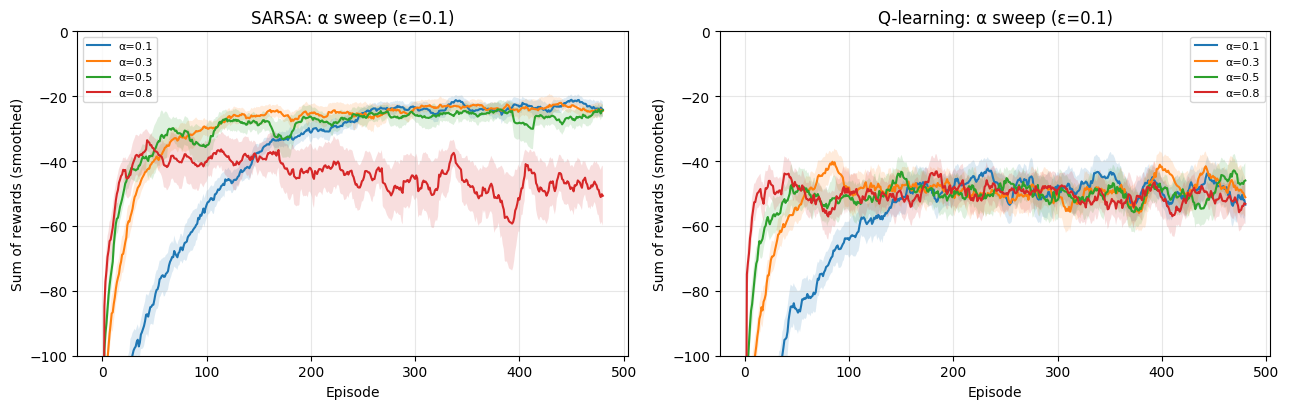

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.2))
for ax, alg, name in zip(axes, [sarsa, qlearning], ["SARSA", "Q-learning"]):
    for a in [0.1, 0.3, 0.5, 0.8]:
        rets, _ = run_many(alg, 30, 500, a, 0.1, 1.0)
        m, lo, hi = ci95(smooth(rets))
        ax.plot(m, label=f"α={a}"); ax.fill_between(np.arange(len(m)), lo, hi, alpha=0.15)
    ax.set_xlabel("Episode"); ax.set_ylabel("Sum of rewards (smoothed)")
    ax.set_ylim(-100, 0); ax.set_title(f"{name}: α sweep (ε=0.1)"); ax.legend(fontsize=8); ax.grid(alpha=0.3)
plt.tight_layout(); plt.show()


## 7. ε exploration schedule sweep

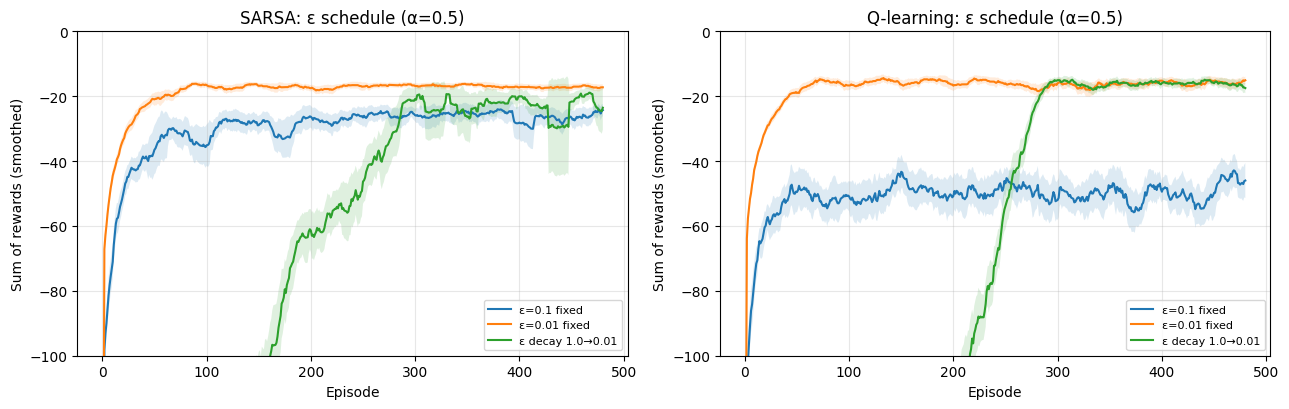

In [8]:
schedules = [("ε=0.1 fixed", 0.1), ("ε=0.01 fixed", 0.01),
             ("ε decay 1.0→0.01", lambda ep: max(0.01, 1.0 - ep / 300))]
fig, axes = plt.subplots(1, 2, figsize=(13, 4.2))
for ax, alg, name in zip(axes, [sarsa, qlearning], ["SARSA", "Q-learning"]):
    for label, eps in schedules:
        rets, _ = run_many(alg, 30, 500, 0.5, eps, 1.0)
        m, lo, hi = ci95(smooth(rets))
        ax.plot(m, label=label); ax.fill_between(np.arange(len(m)), lo, hi, alpha=0.15)
    ax.set_xlabel("Episode"); ax.set_ylabel("Sum of rewards (smoothed)")
    ax.set_ylim(-100, 0); ax.set_title(f"{name}: ε schedule (α=0.5)"); ax.legend(fontsize=8); ax.grid(alpha=0.3)
plt.tight_layout(); plt.show()


## 8. Comparison table

In [9]:
print(f"{'Metric':<35}{'SARSA':>12}{'Q-learning':>15}")
print(f"{'Final 100-ep mean reward':<35}{sarsa_ret[:, -100:].mean():>12.2f}{ql_ret[:, -100:].mean():>15.2f}")
print(f"{'Cliff-fall rate (return ≤ -100)':<35}{(sarsa_ret <= -100).mean():>12.3f}{(ql_ret <= -100).mean():>15.3f}")
def first_cross(rets, thr=-30):
    m = np.convolve(rets.mean(0), np.ones(20)/20, mode='valid')
    idx = np.where(m > thr)[0]
    return int(idx[0]) if len(idx) else -1
print(f"{'First episode mean > -30':<35}{first_cross(sarsa_ret):>12d}{first_cross(ql_ret):>15d}")


Metric                                    SARSA     Q-learning
Final 100-ep mean reward                 -26.62         -48.70
Cliff-fall rate (return ≤ -100)           0.069          0.256
First episode mean > -30                     67             -1
